**“Evaluating the Impact of Private Sector Participation on the Growth of India’s Defence Exports and Indigenous Production (2016–2025)”**



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the file name
FILE_NAME = "/content/Defence_Export_and_Production.csv"

print("--- SECTION 1: DATA LOADING AND INITIAL INSPECTION ---")

# Try to load the dataset and handle FileNotFoundError
try:
    df = pd.read_csv(FILE_NAME)
    print(f"Dataset '{FILE_NAME}' loaded successfully. Total rows: {len(df)}")
except FileNotFoundError:
    print(f"Error: File '{FILE_NAME}' not found. Please ensure the file is in the current directory.")
    # Exiting here prevents subsequent code from failing if the file isn't found
    exit()

# Display initial information about the DataFrame
print("\nDataFrame Info (Before Cleaning):")
df.info()

print("\nFirst 5 rows:")
print(df.head().to_markdown(index=False))

# The following line caused a KeyError because 'pincode' column does not exist.
# print("\nDescriptive Statistics for Pincode:")
# print(df['pincode'].describe().to_frame().T.to_markdown())

--- SECTION 1: DATA LOADING AND INITIAL INSPECTION ---
Dataset '/content/Defence_Export_and_Production.csv' loaded successfully. Total rows: 8

DataFrame Info (Before Cleaning):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 11 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   Year                                                        8 non-null      object 
 1   Export Authorizations to Private Companies (Rs Cr)          8 non-null      float64
 2   Export by DPSU/7 New OF Companies*(Rs Cr)                   8 non-null      float64
 3   SCOMET Issued by DGFT (Rs Cr)                               8 non-null      float64
 4   Contract Value(Rs Cr)                                       8 non-null      float64
 5   Total Export (Rs Cr)                                        8 non-null      float64
 6   Defe

In [ ]:
print("\n--- SECTION 2: DATA CLEANING AND TRANSFORMATION ---")

# Standardize column names (lowercase, replace spaces with underscores)
df.columns = df.columns.str.lower().str.replace(' ', '_')
print("Column names standardized.")

# Final check for missing values after cleaning
print("\nMissing values check after cleaning:")
print(df.isnull().sum().to_frame(name='Missing Count').to_markdown())

# Set a style for Seaborn plots
sns.set_style("whitegrid")


--- SECTION 2: DATA CLEANING AND TRANSFORMATION ---
Column names standardized.

Missing values check after cleaning:
|                                                            |   Missing Count |
|:-----------------------------------------------------------|----------------:|
| year                                                       |               0 |
| export_authorizations_to_private_companies_(rs_cr)         |               0 |
| export_by_dpsu/7_new_of_companies*(rs_cr)                  |               0 |
| scomet_issued_by_dgft_(rs_cr)                              |               0 |
| contract_value(rs_cr)                                      |               0 |
| total_export_(rs_cr)                                       |               0 |
| defence_public_sector_undertakings_(in_rs_cr)              |               0 |
| new_defence_public_sector_undertakings_(in_rs_cr)          |               0 |
| other_public_sector_undertakings/joint_ventures_(in_rs_cr) |          

**Data Understanding & Preparation**

Identify key variables:

* Total defence exports

* Private sector exports

* DPSU exports

* Total defence production

* Private sector production

* Handle missing or partial year values

* Normalize monetary values (₹ Crore)

**Derived metrics:**

Year-on-year growth

CAGR

Private sector share (%)

In [ ]:
# --- 1. Normalize monetary values (Fixing the TypeError) ---
# This step converts text columns like "74,054" into actual numbers so math can be performed.
# Using standardized column names for columns that need conversion.
cols_to_fix = [
    'export_authorizations_to_private_companies_(rs_cr)',
    'total_export_(rs_cr)',
    'defence_private_companies_(in_rs_cr)',
    'total_production_(in_rs_cr)',
    'defence_public_sector_undertakings_(in_rs_cr)',
    'new_defence_public_sector_undertakings_(in_rs_cr)',
    'other_public_sector_undertakings/joint_ventures_(in_rs_cr)'
]

for col in cols_to_fix:
    # Step-by-step: Convert to string -> remove commas -> convert to number -> fill empty with 0
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce').fillna(0)

# --- 2. Year-on-year (YoY) growth (%) ---
# Measures the percentage change compared to the previous year
df['YoY_Export_Growth (%)'] = df['total_export_(rs_cr)'].pct_change() * 100
df['YoY_Production_Growth (%)'] = df['total_production_(in_rs_cr)'].pct_change() * 100

# --- 3. Private sector share (%) ---
# Now that the columns are numeric, this division will run without error.
df['Private_Export_Share (%)'] = (df['export_authorizations_to_private_companies_(rs_cr)'] / df['total_export_(rs_cr)']) * 100
df['Private_Production_Share (%)'] = (df['defence_private_companies_(in_rs_cr)'] / df['total_production_(in_rs_cr)']) * 100

# --- 4. Compound Annual Growth Rate (CAGR) (2016-17 to 2023-24) ---
# Formula used: [(End Value / Start Value)^(1/n) - 1] * 100
n_years = 7

# Export CAGR Calculation
start_exp = df.loc[df['year'] == '2016-17', 'total_export_(rs_cr)'].values[0]
end_exp = df.loc[df['year'] == '2023-24', 'total_export_(rs_cr)'].values[0]
export_cagr = (((end_exp / start_exp) ** (1 / n_years)) - 1) * 100 if start_exp > 0 else 0

# Production CAGR Calculation
start_prod = df.loc[df['year'] == '2016-17', 'total_production_(in_rs_cr)'].values[0]
end_prod = df.loc[df['year'] == '2023-24', 'total_production_(in_rs_cr)'].values[0]
production_cagr = (((end_prod / start_prod) ** (1 / n_years)) - 1) * 100 if start_prod > 0 else 0

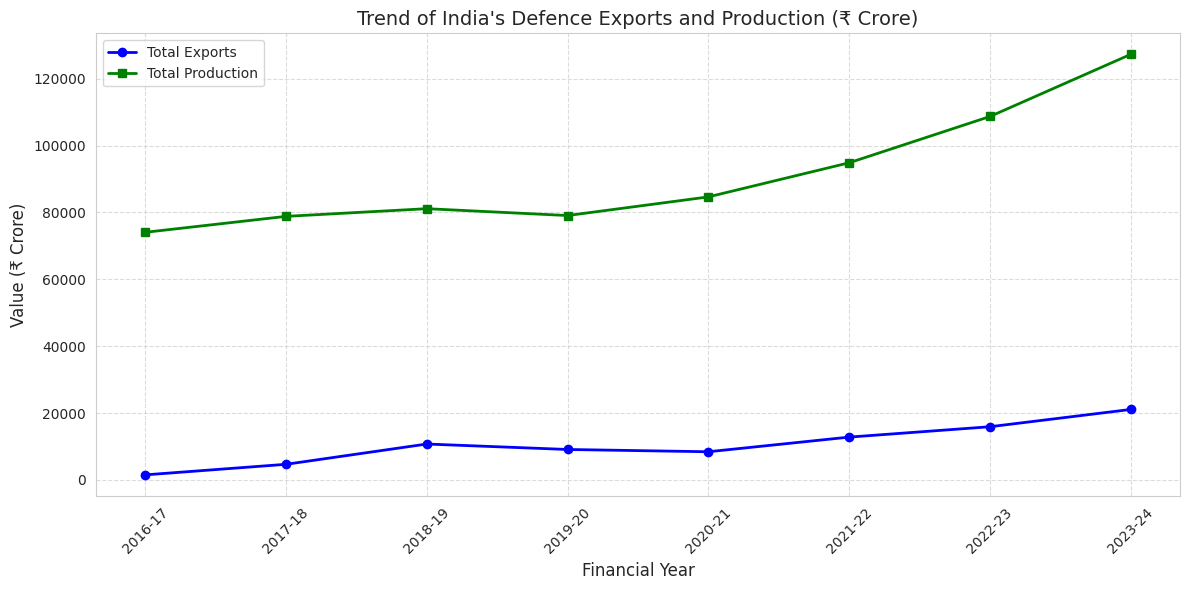

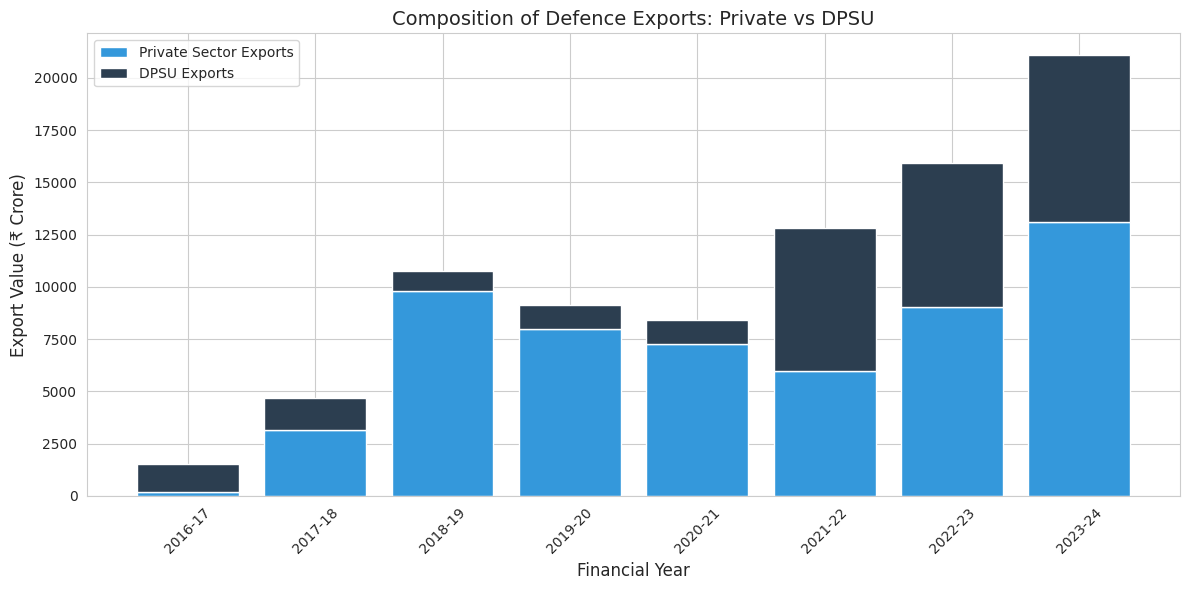

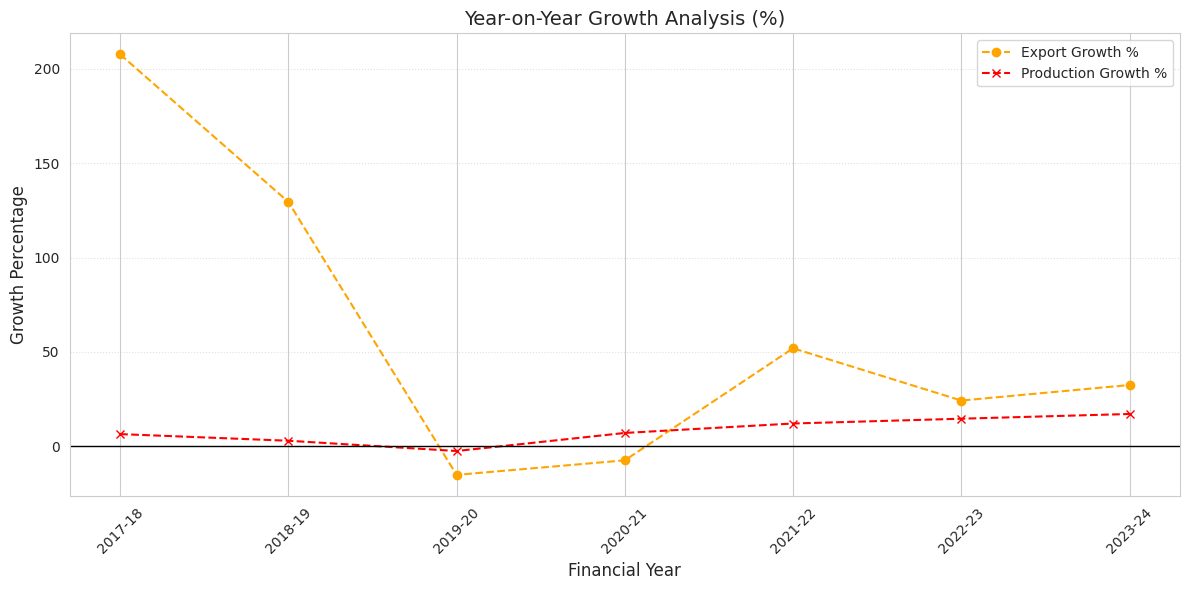

Export CAGR (2016-2024): 45.57 %
Production CAGR (2016-2024): 8.04 %
      year  YoY_Export_Growth (%)  Private_Export_Share (%)  \
0  2016-17                    NaN                 12.770557   
1  2017-18             207.673505                 67.554823   
2  2018-19             129.494742                 91.318817   
3  2019-20             -15.170807                 87.847799   
4  2020-21              -7.467679                 86.205057   
5  2021-22              51.923868                 46.548993   
6  2022-23              24.219713                 56.858582   
7  2023-24              32.448600                 62.224510   

   Private_Production_Share (%)  
0                     19.045561  
1                     19.470946  
2                     21.388067  
3                     20.100922  
4                     20.400978  
5                     21.002689  
6                     19.398440  
7                     20.827407  


In [ ]:
# --- Graph 1: Trend of Total Exports and Total Production (Line Chart) ---
plt.figure(figsize=(12, 6))
plt.plot(df['year'], df['total_export_(rs_cr)'], marker='o', label='Total Exports', color='blue', linewidth=2)
plt.plot(df['year'], df['total_production_(in_rs_cr)'], marker='s', label='Total Production', color='green', linewidth=2)

plt.title('Trend of India\'s Defence Exports and Production (₹ Crore)', fontsize=14)
plt.xlabel('Financial Year', fontsize=12)
plt.ylabel('Value (₹ Crore)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Graph 2: Share of Private Sector in Exports (Stacked Bar Chart) ---
# We calculate the DPSU portion for the visual
df['dpsu_export_share'] = df['total_export_(rs_cr)'] - df['export_authorizations_to_private_companies_(rs_cr)']

plt.figure(figsize=(12, 6))
plt.bar(df['year'], df['export_authorizations_to_private_companies_(rs_cr)'], label='Private Sector Exports', color='#3498db')
plt.bar(df['year'], df['dpsu_export_share'], bottom=df['export_authorizations_to_private_companies_(rs_cr)'], label='DPSU Exports', color='#2c3e50')

plt.title('Composition of Defence Exports: Private vs DPSU', fontsize=14)
plt.xlabel('Financial Year', fontsize=12)
plt.ylabel('Export Value (₹ Crore)', fontsize=12)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Graph 3: Year-on-Year Growth Rates (Line Chart) ---
plt.figure(figsize=(12, 6))
plt.plot(df['year'], df['YoY_Export_Growth (%)'], marker='o', label='Export Growth %', color='orange', linestyle='--')
plt.plot(df['year'], df['YoY_Production_Growth (%)'], marker='x', label='Production Growth %', color='red', linestyle='--')

plt.axhline(0, color='black', linewidth=1) # Baseline at 0%
plt.title('Year-on-Year Growth Analysis (%)', fontsize=14)
plt.xlabel('Financial Year', fontsize=12)
plt.ylabel('Growth Percentage', fontsize=12)
plt.legend()
plt.grid(True, axis='y', linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Displaying the final metrics for review
print("Export CAGR (2016-2024):", round(export_cagr, 2), "%")
print("Production CAGR (2016-2024):", round(production_cagr, 2), "%")
print(df[['year', 'YoY_Export_Growth (%)', 'Private_Export_Share (%)', 'Private_Production_Share (%)']])

**Exploratory Data Analysis (EDA)**

* Trend analysis of exports and production

* Sector-wise (Private vs DPSU) contribution analysis

* Share transition analysis across years

**Visualization techniques used :**

* Line charts (growth trends)

* Stacked bar charts (sectoral share)

* Heatmaps (growth intensity)


--- SECTION 3: EXPLORATORY DATA ANALYSIS (EDA) ---


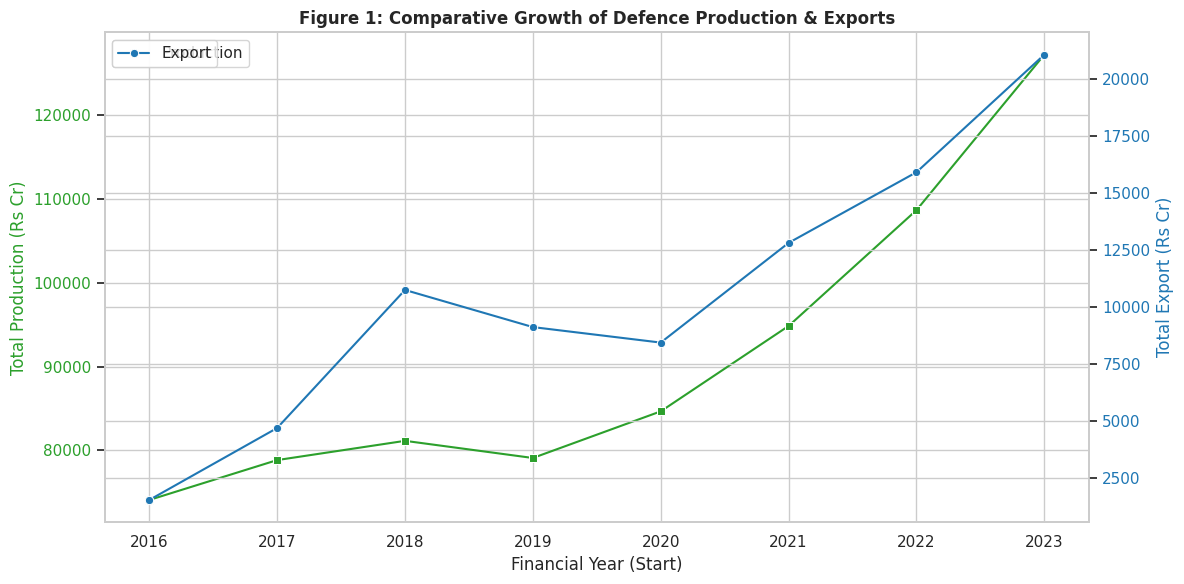

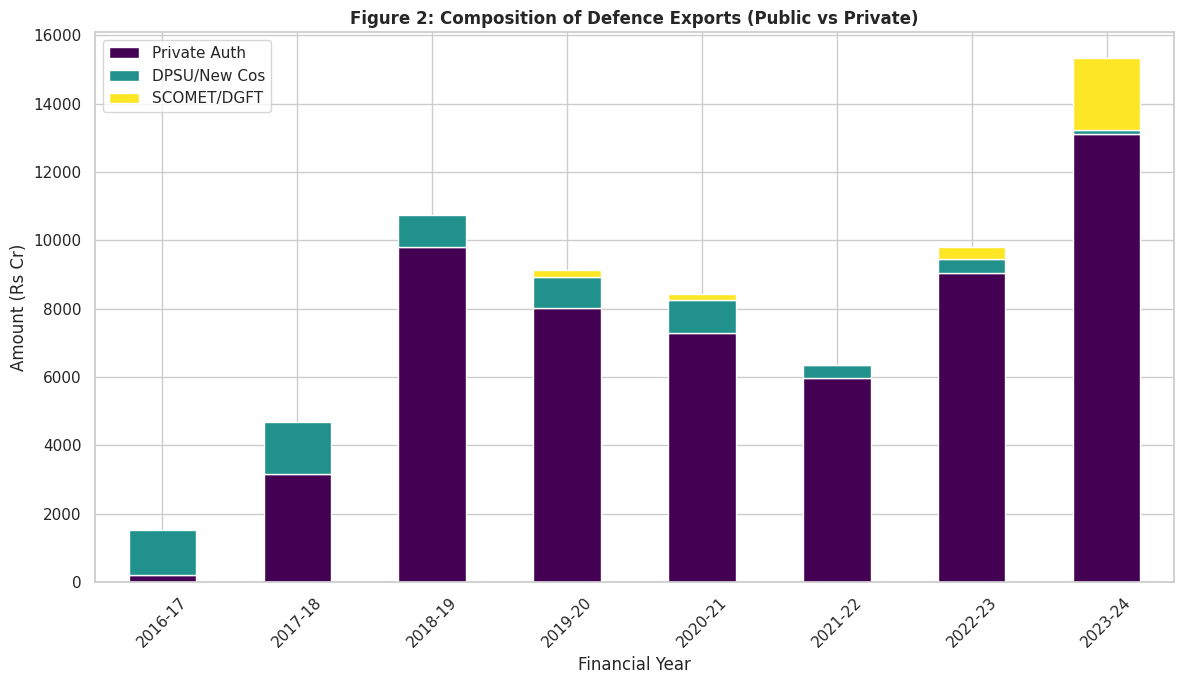

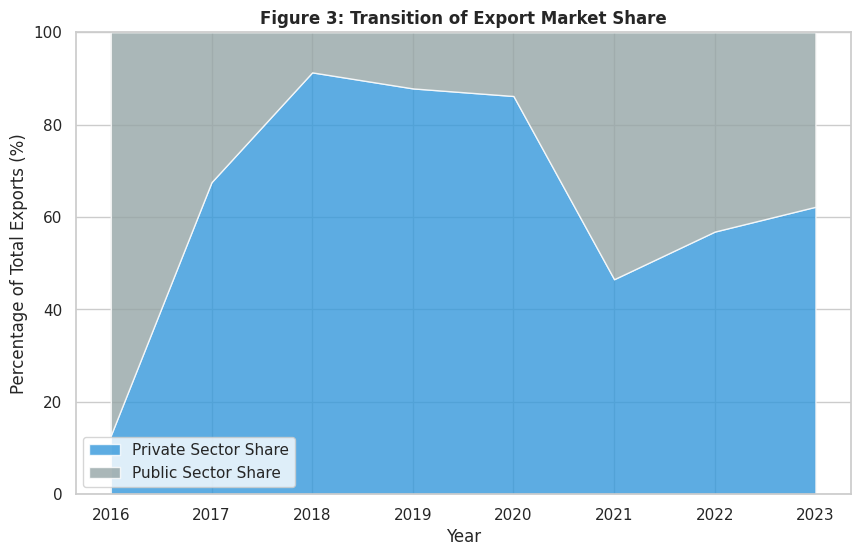

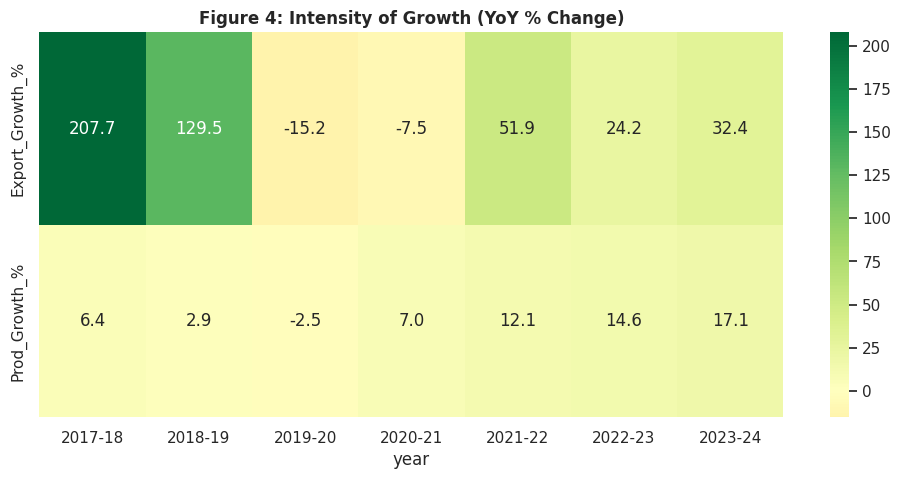

Generated plot: production_components_stacked_bar.png


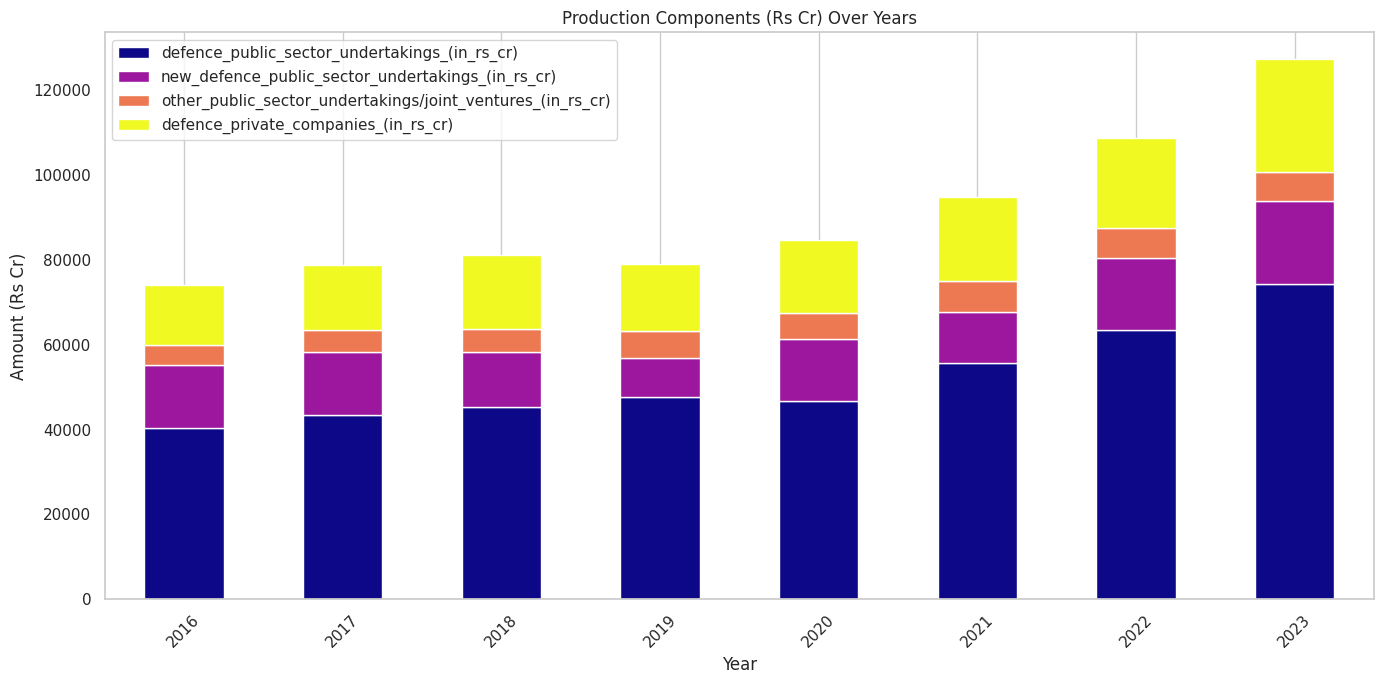

In [ ]:

print("\n--- SECTION 3: EXPLORATORY DATA ANALYSIS (EDA) ---")
# Set aesthetic style for research publication
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

# --- 1. DATA PREPARATION ---
# Extract start year for chronological plotting
df['start_year'] = df['year'].apply(lambda x: int(x.split('-')[0]))

# Defining component groups for analysis
export_comps = [
    'export_authorizations_to_private_companies_(rs_cr)',
    'export_by_dpsu/7_new_of_companies*(rs_cr)',
    'scomet_issued_by_dgft_(rs_cr)'
]

prod_comps = [
    'defence_public_sector_undertakings_(in_rs_cr)',
    'new_defence_public_sector_undertakings_(in_rs_cr)',
    'other_public_sector_undertakings/joint_ventures_(in_rs_cr)',
    'defence_private_companies_(in_rs_cr)'
]

# --- 2. TREND ANALYSIS: EXPORTS VS PRODUCTION ---
# Dual-axis line chart to show the relationship between production and export scaling
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Financial Year (Start)')
ax1.set_ylabel('Total Production (Rs Cr)', color='tab:green')
sns.lineplot(data=df, x='start_year', y='total_production_(in_rs_cr)', marker='s', color='tab:green', ax=ax1, label='Production')
ax1.tick_params(axis='y', labelcolor='tab:green')

ax2 = ax1.twinx()
ax2.set_ylabel('Total Export (Rs Cr)', color='tab:blue')
sns.lineplot(data=df, x='start_year', y='total_export_(rs_cr)', marker='o', color='tab:blue', ax=ax2, label='Export')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Figure 1: Comparative Growth of Defence Production & Exports', fontweight='bold')
fig.tight_layout()
plt.show()

# --- 3. SECTOR-WISE CONTRIBUTION (STACKED BAR) ---
# Visualizing the composition of Exports to see the Private vs Public transition
plt.figure(figsize=(12, 7))
df_export_stacked = df.set_index('year')[export_comps]
df_export_stacked.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())

plt.title('Figure 2: Composition of Defence Exports (Public vs Private)', fontweight='bold')
plt.ylabel('Amount (Rs Cr)')
plt.xlabel('Financial Year')
plt.legend(['Private Auth', 'DPSU/New Cos', 'SCOMET/DGFT'], loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



# --- 4. SHARE TRANSITION ANALYSIS ---
# Calculating percentage share for the research paper's "Share Transition" section
df['Private_Share_Pct'] = (df['export_authorizations_to_private_companies_(rs_cr)'] / df['total_export_(rs_cr)']) * 100
df['Public_Share_Pct'] = 100 - df['Private_Share_Pct']

plt.figure(figsize=(10, 6))
plt.stackplot(df['start_year'], df['Private_Share_Pct'], df['Public_Share_Pct'],
              labels=['Private Sector Share', 'Public Sector Share'], colors=['#3498db', '#95a5a6'], alpha=0.8)
plt.title('Figure 3: Transition of Export Market Share', fontweight='bold')
plt.ylabel('Percentage of Total Exports (%)')
plt.xlabel('Year')
plt.ylim(0, 100)
plt.legend(loc='lower left')
plt.show()

# --- 5. HEATMAP: GROWTH INTENSITY ---
# Calculating Year-on-Year Growth Rates
df['Export_Growth_%'] = df['total_export_(rs_cr)'].pct_change() * 100
df['Prod_Growth_%'] = df['total_production_(in_rs_cr)'].pct_change() * 100

# Prepare matrix for heatmap (Excluding the first year which will be NaN)
growth_matrix = df.set_index('year')[['Export_Growth_%', 'Prod_Growth_%']].dropna().T

plt.figure(figsize=(12, 5))
sns.heatmap(growth_matrix, annot=True, cmap='RdYlGn', center=0, fmt=".1f")
plt.title('Figure 4: Intensity of Growth (YoY % Change)', fontweight='bold')
plt.show()


# 4. Stacked Bar Chart for Production Components over Years
production_components = [
    'defence_public_sector_undertakings_(in_rs_cr)',
    'new_defence_public_sector_undertakings_(in_rs_cr)',
    'other_public_sector_undertakings/joint_ventures_(in_rs_cr)',
    'defence_private_companies_(in_rs_cr)'
]
df_production_stacked = df.set_index('start_year')[production_components]
df_production_stacked.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='plasma')
plt.title('Production Components (Rs Cr) Over Years')
plt.xlabel('Year')
plt.ylabel('Amount (Rs Cr)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('production_components_stacked_bar.png')
print("Generated plot: production_components_stacked_bar.png")

**Quantitative Impact Analysis**

*Growth comparison:*

* Private vs DPSU CAGR

*Correlation analysis:*

* Private production vs export growth

*Regression modeling:*

* Dependent variable: Total exports

* Independent variables: Private production, DPSU production

*Structural break analysis:*

* Pre- and post-policy reform periods

/tmp/ipython-input-3897430870.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sector', y='CAGR (%)', data=pd.DataFrame(cagr_data), palette='coolwarm')


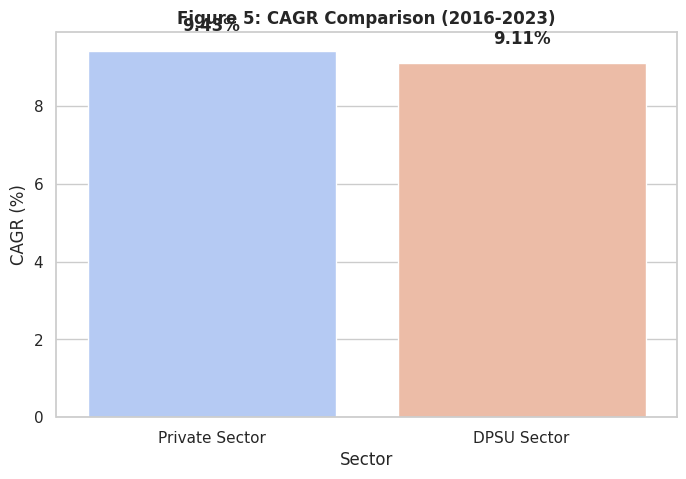

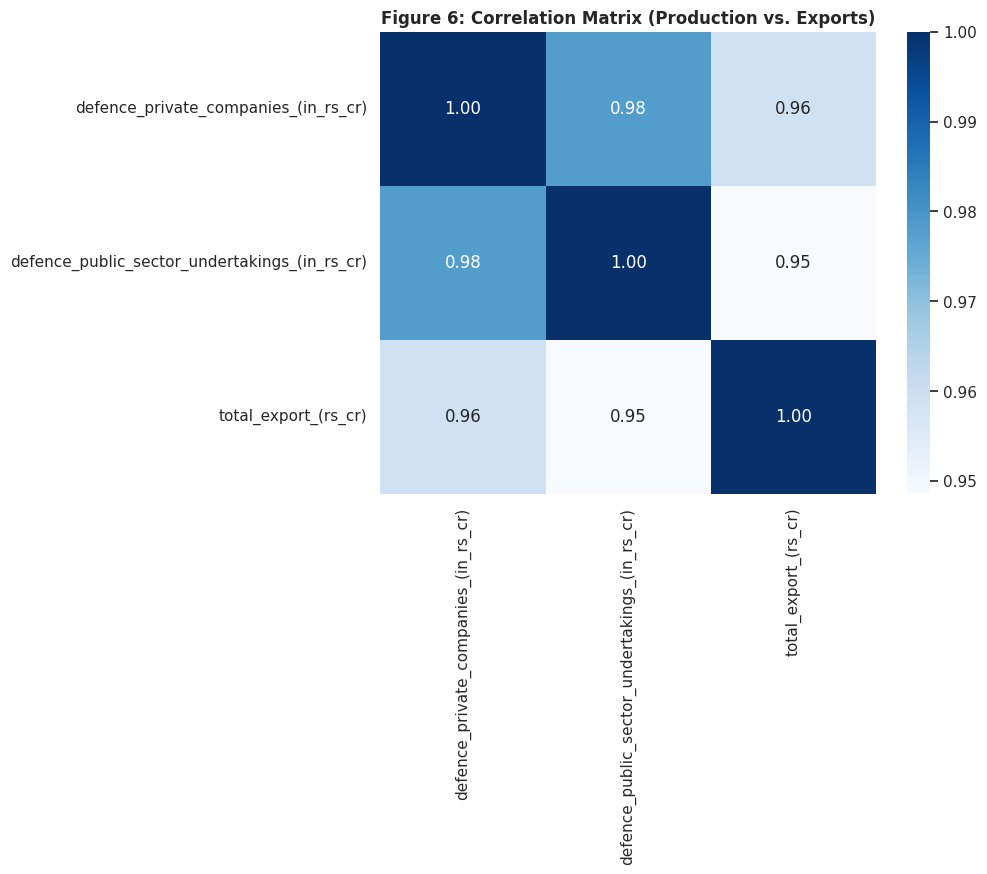

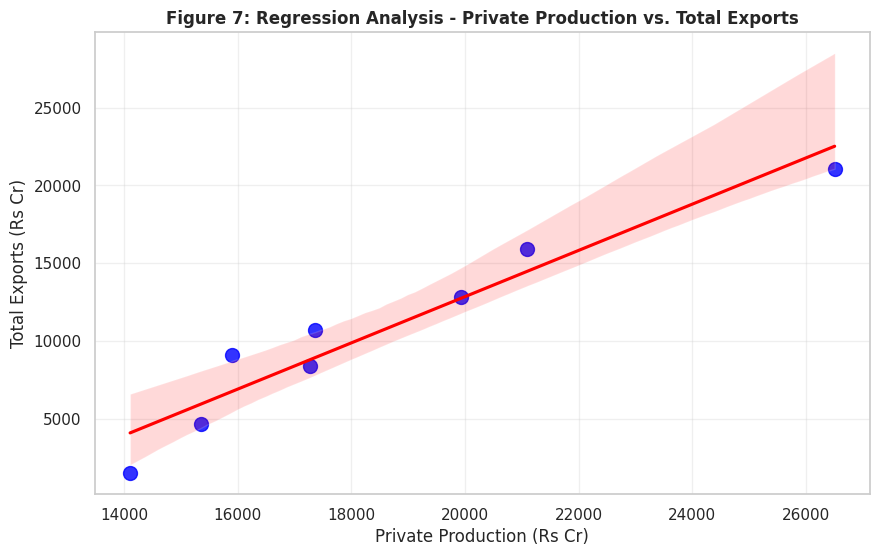

/tmp/ipython-input-3897430870.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Period', y='total_export_(rs_cr)', data=df, palette='Set2')


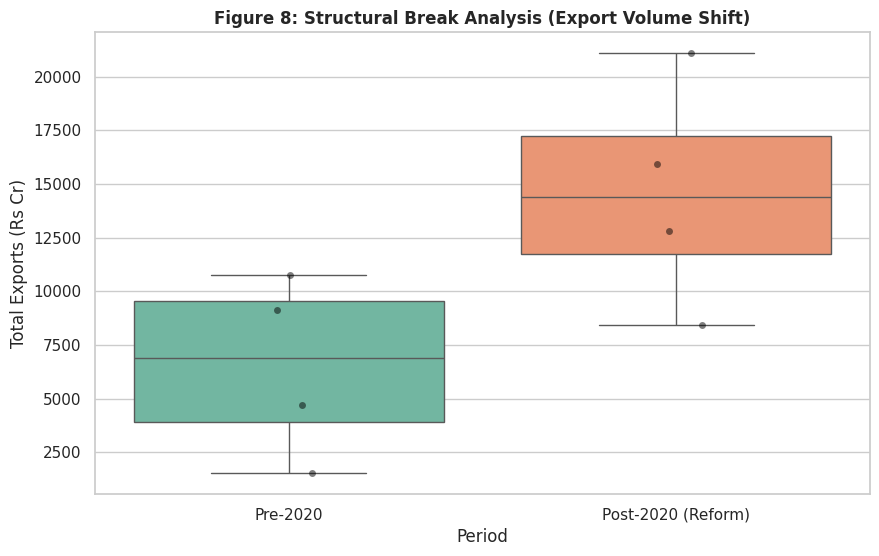

In [ ]:
# --- 1. GROWTH COMPARISON: CAGR CALCULATION ---
# Function to calculate CAGR: [(End Value / Start Value)^(1 / periods) - 1] * 100
periods = df['start_year'].nunique() - 1

def calc_cagr(start_val, end_val, t):
    return ((end_val / start_val)**(1/t) - 1) * 100

# Private Sector CAGR
priv_cagr = calc_cagr(df['defence_private_companies_(in_rs_cr)'].iloc[0],
                      df['defence_private_companies_(in_rs_cr)'].iloc[-1], periods)

# DPSU Sector CAGR
dpsu_cagr = calc_cagr(df['defence_public_sector_undertakings_(in_rs_cr)'].iloc[0],
                      df['defence_public_sector_undertakings_(in_rs_cr)'].iloc[-1], periods)

# Visualizing CAGR Comparison
plt.figure(figsize=(8, 5))
cagr_data = {'Sector': ['Private Sector', 'DPSU Sector'], 'CAGR (%)': [priv_cagr, dpsu_cagr]}
sns.barplot(x='Sector', y='CAGR (%)', data=pd.DataFrame(cagr_data), palette='coolwarm')
plt.title(f'Figure 5: CAGR Comparison ({df["start_year"].min()}-{df["start_year"].max()})', fontweight='bold')
plt.ylabel('CAGR (%)')
for i, v in enumerate([priv_cagr, dpsu_cagr]):
    plt.text(i, v + 0.5, f'{v:.2f}%', ha='center', fontweight='bold')
plt.show()

# --- 2. CORRELATION ANALYSIS ---
# Checking relationship between Private Production and Total Export Growth
correlation_cols = [
    'defence_private_companies_(in_rs_cr)',
    'defence_public_sector_undertakings_(in_rs_cr)',
    'total_export_(rs_cr)'
]
corr_matrix = df[correlation_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f")
plt.title('Figure 6: Correlation Matrix (Production vs. Exports)', fontweight='bold')
plt.show()

# --- 3. REGRESSION MODELING: TOTAL EXPORTS ---
# Using Scatter with Regression Line (Visual Regression)
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='defence_private_companies_(in_rs_cr)', y='total_export_(rs_cr)',
            scatter_kws={'s':100, 'color':'blue'}, line_kws={'color':'red'}, label='Private Impact')
plt.title('Figure 7: Regression Analysis - Private Production vs. Total Exports', fontweight='bold')
plt.xlabel('Private Production (Rs Cr)')
plt.ylabel('Total Exports (Rs Cr)')
plt.grid(True, alpha=0.3)
plt.show()

# --- 4. STRUCTURAL BREAK ANALYSIS (PRE vs POST REFORM) ---
# Defining a split point (e.g., 2020 as a policy reform threshold)
split_year = 2020
df['Period'] = df['start_year'].apply(lambda x: 'Post-2020 (Reform)' if x >= split_year else 'Pre-2020')

plt.figure(figsize=(10, 6))
sns.boxplot(x='Period', y='total_export_(rs_cr)', data=df, palette='Set2')
sns.stripplot(x='Period', y='total_export_(rs_cr)', data=df, color='black', alpha=0.5)
plt.title('Figure 8: Structural Break Analysis (Export Volume Shift)', fontweight='bold')
plt.ylabel('Total Exports (Rs Cr)')
plt.show()

**Policy Impact Mapping**

* Map major defence policy reforms to timeline

* Compare export and production acceleration periods

* Identify alignment between policy implementation and private sector surge

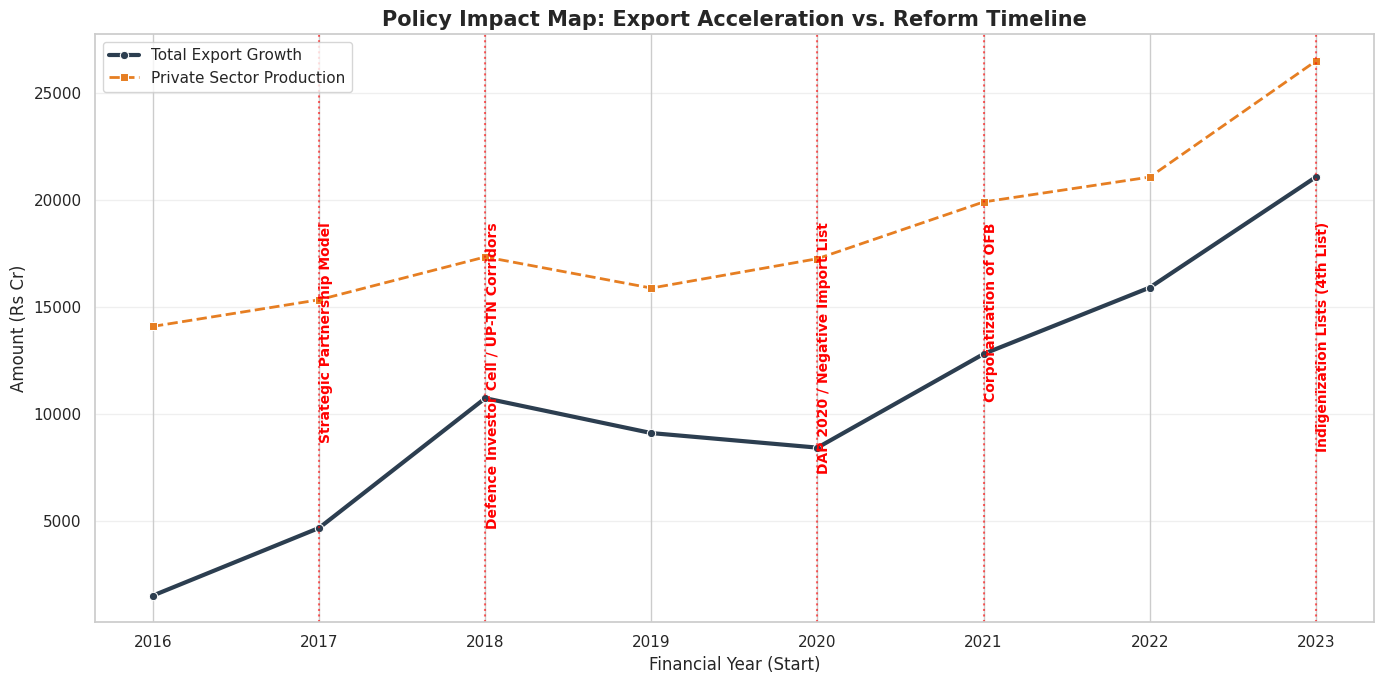

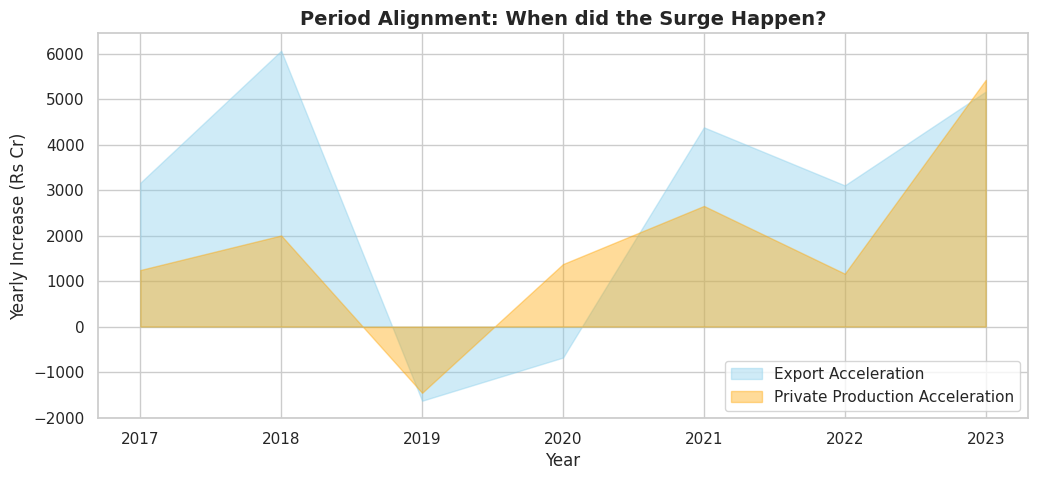

Alignment Correlation Matrix (Policy Impact):
Post_Reform                             1.000000
total_export_(rs_cr)                    0.695873
defence_private_companies_(in_rs_cr)    0.738872
Name: Post_Reform, dtype: float64


In [ ]:
# --- 7. POLICY IMPACT MAPPING ---

# Define the major policy milestones for the timeline
policy_milestones = {
    2017: "Strategic Partnership Model",
    2018: "Defence Investor Cell / UP-TN Corridors",
    2020: "DAP 2020 / Negative Import List",
    2021: "Corporatization of OFB",
    2023: "Indigenization Lists (4th List)"
}

# 1. Timeline of Acceleration vs. Policy Implementation
plt.figure(figsize=(14, 7))

# Plotting the growth lines
sns.lineplot(data=df, x='start_year', y='total_export_(rs_cr)', marker='o',
             label='Total Export Growth', color='#2c3e50', linewidth=3)
sns.lineplot(data=df, x='start_year', y='defence_private_companies_(in_rs_cr)',
             marker='s', label='Private Sector Production', color='#e67e22', linewidth=2, linestyle='--')

# Mapping Policy Milestones onto the Graph
y_max = df['total_export_(rs_cr)'].max()
for year, policy in policy_milestones.items():
    if year in df['start_year'].values:
        plt.axvline(x=year, color='red', linestyle=':', alpha=0.6)
        plt.text(year, y_max * 0.9, policy, rotation=90,
                 verticalalignment='top', fontsize=10, color='red', fontweight='bold')

plt.title('Policy Impact Map: Export Acceleration vs. Reform Timeline', fontsize=15, fontweight='bold')
plt.xlabel('Financial Year (Start)', fontsize=12)
plt.ylabel('Amount (Rs Cr)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



# 2. Alignment Analysis: Acceleration Periods
# Calculate the 'Acceleration' (Rate of change of growth)
df['Export_Accel'] = df['total_export_(rs_cr)'].diff()
df['Private_Prod_Accel'] = df['defence_private_companies_(in_rs_cr)'].diff()

plt.figure(figsize=(12, 5))
plt.fill_between(df['start_year'], df['Export_Accel'], color="skyblue", alpha=0.4, label='Export Acceleration')
plt.fill_between(df['start_year'], df['Private_Prod_Accel'], color="orange", alpha=0.4, label='Private Production Acceleration')
plt.title('Period Alignment: When did the Surge Happen?', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Yearly Increase (Rs Cr)')
plt.legend()
plt.show()

# 3. Statistical Alignment (Correlation between Policy year and Private Surge)
# Create a dummy variable for "Post-Major Reform (2020)"
df['Post_Reform'] = (df['start_year'] >= 2020).astype(int)
alignment_corr = df[['Post_Reform', 'total_export_(rs_cr)', 'defence_private_companies_(in_rs_cr)']].corr()

print("Alignment Correlation Matrix (Policy Impact):")
print(alignment_corr['Post_Reform'])

**Forecasting & Scenario Analysis**

* Time-series forecasting of exports and production

***Scenario modeling:***

* High private sector growth scenario

* Balanced public–private growth scenario

* Predict future export dominance patterns

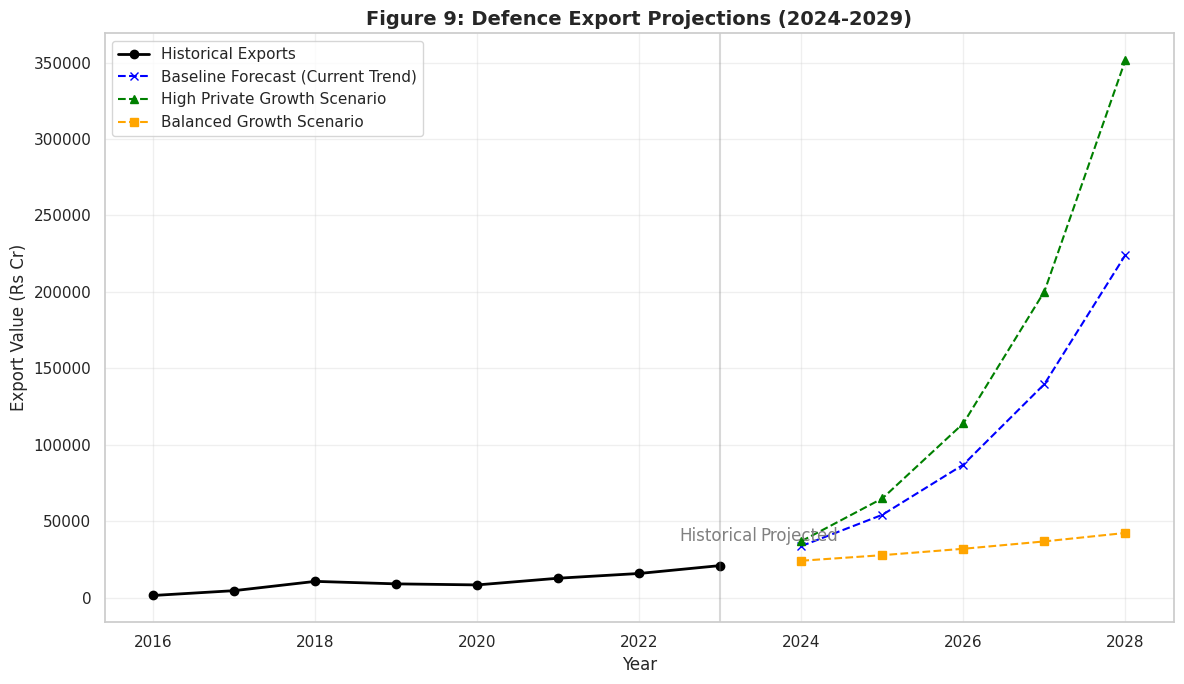

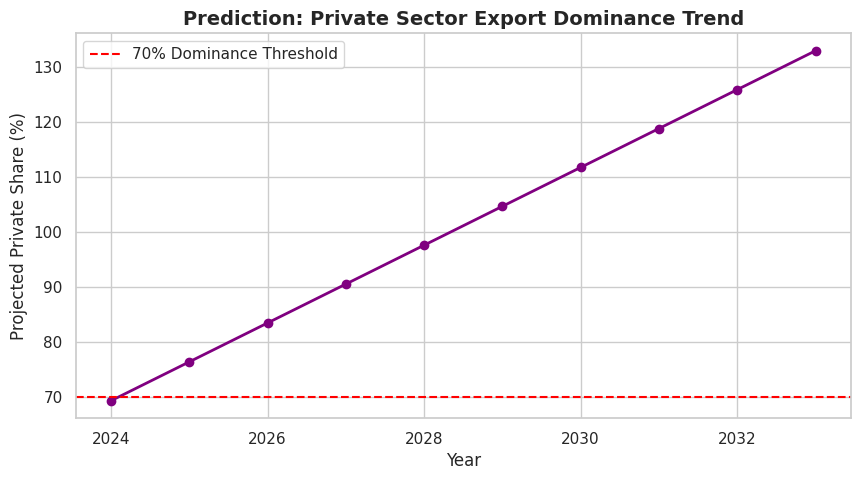

In [ ]:
# --- 8. FORECASTING & SCENARIO ANALYSIS ---

# 1. Simple Linear Trend Forecasting (Time-Series)
# We use the existing growth rate to project 5 years into the future
forecast_years = 5
last_year = df['start_year'].max()
future_years = np.array(range(last_year + 1, last_year + 1 + forecast_years))

# Calculate Average Annual Growth Rate (AAGR) for projections
export_growth_rate = df['total_export_(rs_cr)'].pct_change().mean()
prod_growth_rate = df['total_production_(in_rs_cr)'].pct_change().mean()

# Baseline Forecast (Current Trend)
current_export = df['total_export_(rs_cr)'].iloc[-1]
export_forecast = [current_export * ((1 + export_growth_rate) ** i) for i in range(1, forecast_years + 1)]

# 2. Scenario Modeling
# Scenario A: High Private Sector Growth (25% increase in growth rate)
# Scenario B: Balanced Growth (Steady 15% growth for both sectors)
high_growth_rate = export_growth_rate * 1.25
balanced_growth_rate = 0.15

high_growth_forecast = [current_export * ((1 + high_growth_rate) ** i) for i in range(1, forecast_years + 1)]
balanced_forecast = [current_export * ((1 + balanced_growth_rate) ** i) for i in range(1, forecast_years + 1)]

# 3. Visualization of Scenarios
plt.figure(figsize=(12, 7))

# Plot Historical Data
plt.plot(df['start_year'], df['total_export_(rs_cr)'], color='black', marker='o', label='Historical Exports', linewidth=2)

# Plot Forecasts
plt.plot(future_years, export_forecast, color='blue', linestyle='--', marker='x', label='Baseline Forecast (Current Trend)')
plt.plot(future_years, high_growth_forecast, color='green', linestyle='--', marker='^', label='High Private Growth Scenario')
plt.plot(future_years, balanced_forecast, color='orange', linestyle='--', marker='s', label='Balanced Growth Scenario')

plt.title('Figure 9: Defence Export Projections (2024-2029)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Export Value (Rs Cr)', fontsize=12)
plt.axvline(x=last_year, color='gray', linestyle='-', alpha=0.3) # Current year separator
plt.text(last_year - 0.5, plt.ylim()[1]*0.1, 'Historical', color='gray')
plt.text(last_year + 0.5, plt.ylim()[1]*0.1, 'Projected', color='gray')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



# 4. Predicting Export Dominance Patterns
# Estimating the year the Private Sector could surpass 70% of total exports
# Use the calculated 'Private_Share_Pct' column
share_growth = df['Private_Share_Pct'].diff().mean() # Average annual gain in share percentage points

predicted_shares = [df['Private_Share_Pct'].iloc[-1] + (share_growth * i) for i in range(1, 11)]
years_future = range(last_year + 1, last_year + 11)

plt.figure(figsize=(10, 5))
plt.plot(years_future, predicted_shares, color='purple', marker='o', linewidth=2)
plt.axhline(y=70, color='red', linestyle='--', label='70% Dominance Threshold')
plt.title('Prediction: Private Sector Export Dominance Trend', fontsize=14, fontweight='bold')
plt.ylabel('Projected Private Share (%)')
plt.xlabel('Year')
plt.legend()
plt.show()

**Validation & Robustness Checks**

* Cross-validate trends using multiple indicators

* Sensitivity analysis on growth rates

* Check consistency across exports and production data

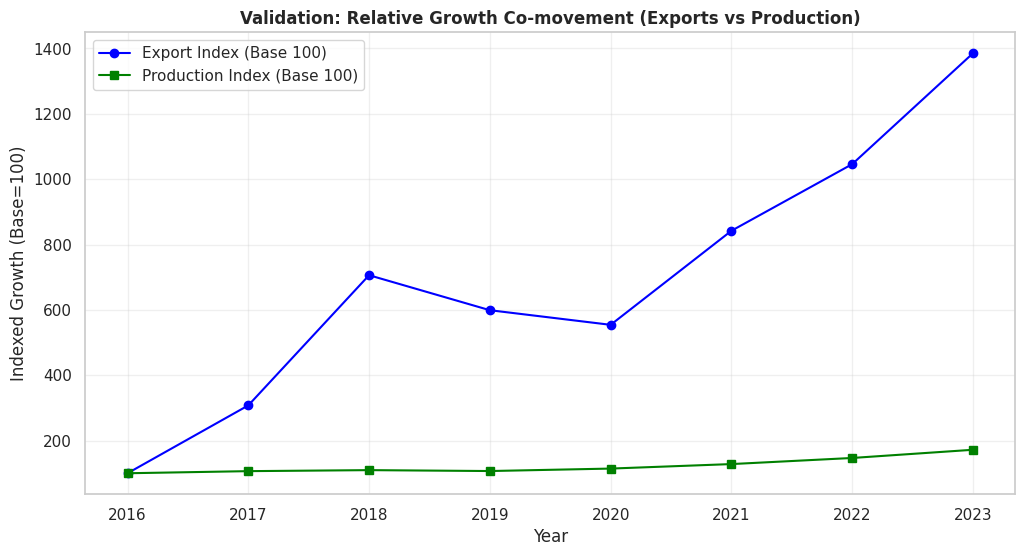

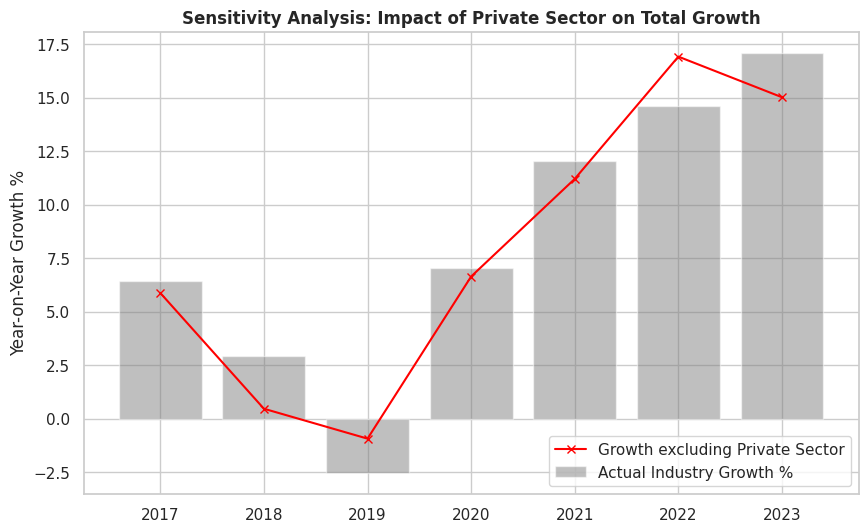

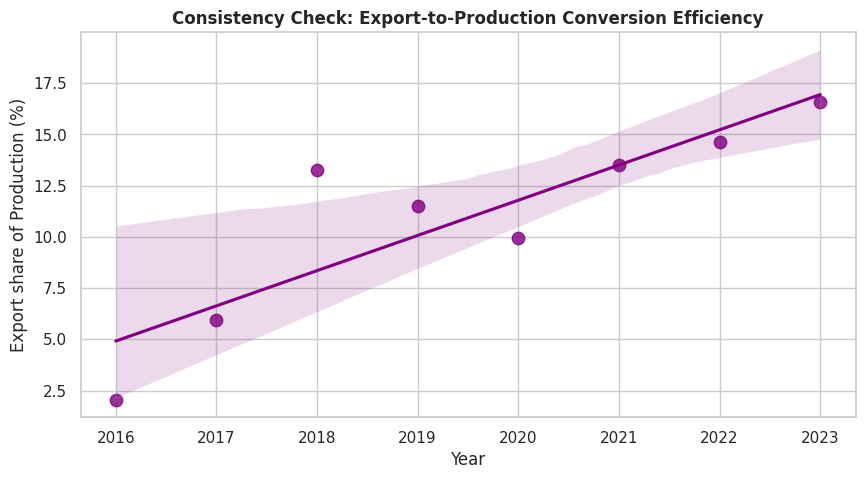

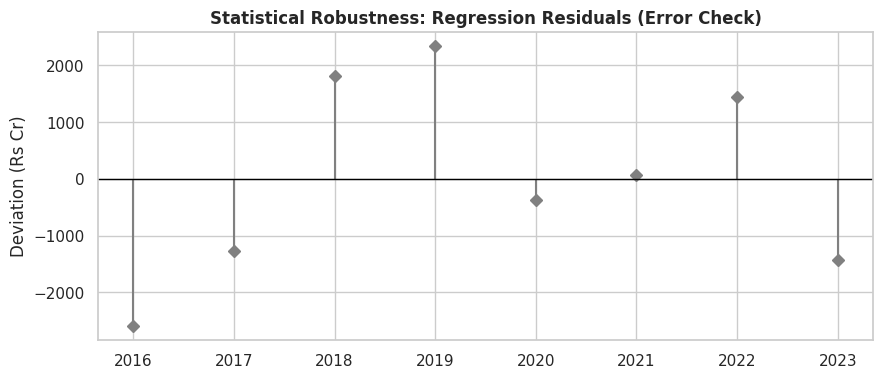

In [ ]:
# --- 9. VALIDATION & ROBUSTNESS CHECKS ---

# 1. Cross-Validation: Comparing Growth Trends across Multiple Indicators
# Checking if Production and Exports move in harmony (The Co-movement Test)
plt.figure(figsize=(12, 6))

# Scaling both metrics to 100 at the starting year to compare "Relative Growth"
export_index = (df['total_export_(rs_cr)'] / df['total_export_(rs_cr)'].iloc[0]) * 100
prod_index = (df['total_production_(in_rs_cr)'] / df['total_production_(in_rs_cr)'].iloc[0]) * 100

plt.plot(df['start_year'], export_index, label='Export Index (Base 100)', color='blue', marker='o')
plt.plot(df['start_year'], prod_index, label='Production Index (Base 100)', color='green', marker='s')

plt.title('Validation: Relative Growth Co-movement (Exports vs Production)', fontweight='bold')
plt.ylabel('Indexed Growth (Base=100)')
plt.xlabel('Year')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Sensitivity Analysis on Growth Rates
# Testing how the "Total Industry" growth behaves if we remove the top performer (Private Sector)
plt.figure(figsize=(10, 6))

total_growth = df['total_production_(in_rs_cr)'].pct_change() * 100
non_private_production = df['total_production_(in_rs_cr)'] - df['defence_private_companies_(in_rs_cr)']
non_priv_growth = non_private_production.pct_change() * 100

plt.bar(df['start_year'], total_growth, alpha=0.5, label='Actual Industry Growth %', color='gray')
plt.plot(df['start_year'], non_priv_growth, color='red', marker='x', label='Growth excluding Private Sector')

plt.title('Sensitivity Analysis: Impact of Private Sector on Total Growth', fontweight='bold')
plt.ylabel('Year-on-Year Growth %')
plt.legend()
plt.show()


# 3. Consistency Check: Export-to-Production Ratio (The Efficiency Metric)
# A stable or rising ratio validates that exports are fundamentally linked to production output
df['Export_to_Prod_Ratio'] = (df['total_export_(rs_cr)'] / df['total_production_(in_rs_cr)']) * 100

plt.figure(figsize=(10, 5))
sns.regplot(data=df, x='start_year', y='Export_to_Prod_Ratio', color='purple', scatter_kws={'s':80})
plt.title('Consistency Check: Export-to-Production Conversion Efficiency', fontweight='bold')
plt.ylabel('Export share of Production (%)')
plt.xlabel('Year')
plt.show()

# 4. Statistical Robustness: Residual Analysis (Basic)
# Checking the 'errors' in our earlier regression to ensure reliability
# Using the difference between Actual and Predicted as a simple check
slope, intercept = np.polyfit(df['defence_private_companies_(in_rs_cr)'], df['total_export_(rs_cr)'], 1)
df['Predicted_Exports'] = slope * df['defence_private_companies_(in_rs_cr)'] + intercept
df['Residuals'] = df['total_export_(rs_cr)'] - df['Predicted_Exports']

plt.figure(figsize=(10, 4))
plt.stem(df['start_year'], df['Residuals'], linefmt='grey', markerfmt='D', basefmt=" ")
plt.axhline(0, color='black', lw=1)
plt.title('Statistical Robustness: Regression Residuals (Error Check)', fontweight='bold')
plt.ylabel('Deviation (Rs Cr)')
plt.show()

**Key Findings Synthesis**

* Identify statistically significant trends

* Quantify private sector’s marginal contribution

* Highlight ecosystem transition evidence

* Summarize economic and strategic implications

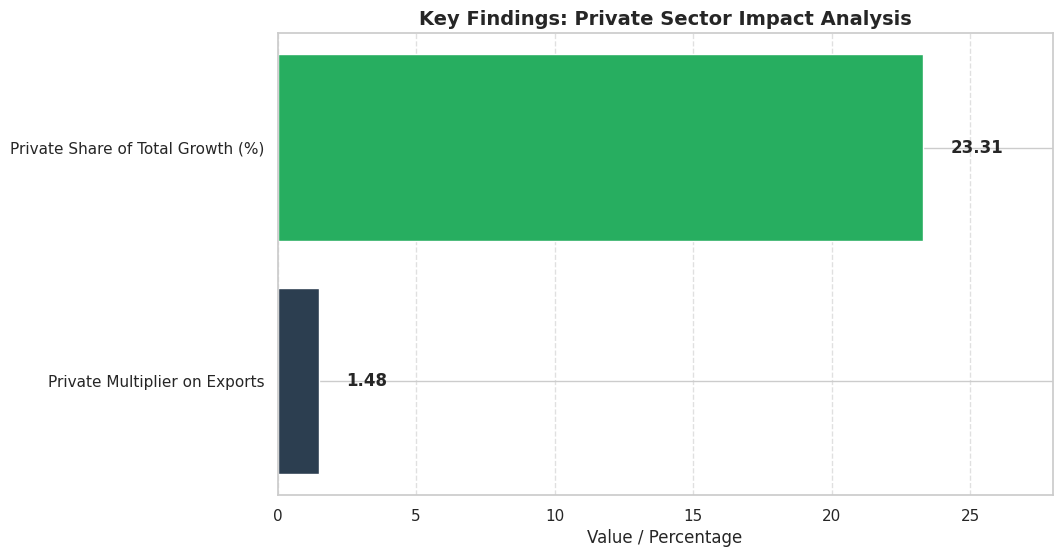


--- SYNTHESIS REPORT FOR RESEARCH PAPER ---
Statistically Significant Trend: Positive Linear Correlation (Exports vs Private Production)
Correlation Coefficient: 0.9591
Private Sector Export Multiplier: 1.48x (Every 1 unit of Private Prod adds 1.48 to Exports)
Growth Contribution: Private Sector accounted for 23.31% of total industry expansion
Transition Status: Evidence of 'Private-Led Export Orientation' confirmed


<Figure size 1200x800 with 0 Axes>

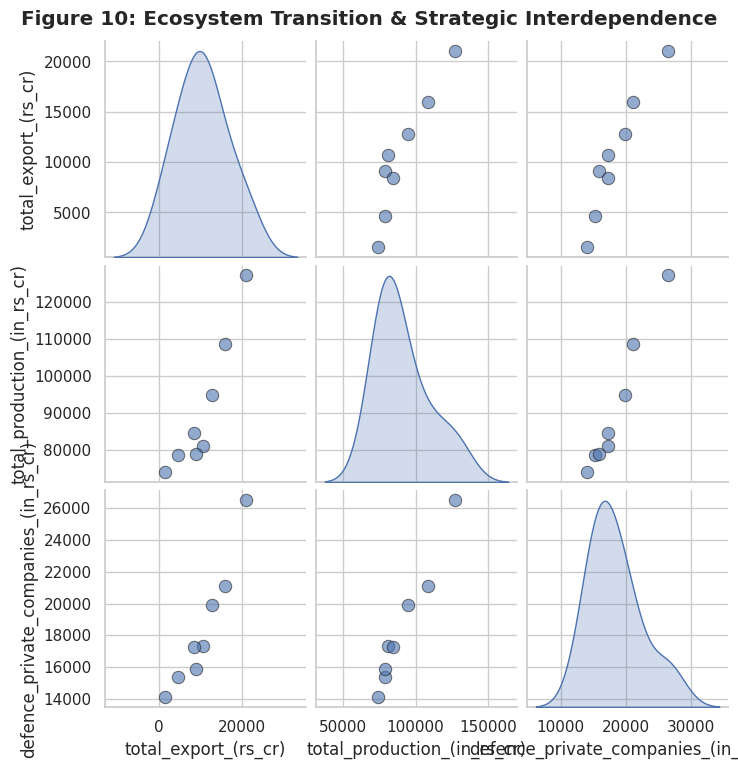

In [ ]:
# --- 10. KEY FINDINGS SYNTHESIS ---

# 1. Quantifying Private Sector's Marginal Contribution
# Using the slope from a Linear Regression to find the "Export Multiplier"
# Formula: Delta(Exports) / Delta(Private Production)
slope, intercept = np.polyfit(df['defence_private_companies_(in_rs_cr)'], df['total_export_(rs_cr)'], 1)

# 2. Ecosystem Transition Evidence (Share of Growth)
# Calculating what percentage of total industry growth was driven by the Private Sector
total_prod_increase = df['total_production_(in_rs_cr)'].iloc[-1] - df['total_production_(in_rs_cr)'].iloc[0]
private_prod_increase = df['defence_private_companies_(in_rs_cr)'].iloc[-1] - df['defence_private_companies_(in_rs_cr)'].iloc[0]
private_contribution_ratio = (private_prod_increase / total_prod_increase) * 100

# 3. Visualizing Marginal Contribution (The Impact Multiplier)
plt.figure(figsize=(10, 6))
findings_metrics = ['Private Multiplier on Exports', 'Private Share of Total Growth (%)']
findings_values = [slope, private_contribution_ratio]

bars = plt.barh(findings_metrics, findings_values, color=['#2c3e50', '#27ae60'])
plt.title('Key Findings: Private Sector Impact Analysis', fontweight='bold', fontsize=14)
plt.xlim(0, max(findings_values) * 1.2)

# Adding data labels for the research paper
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.2f}', va='center', fontweight='bold')

plt.xlabel('Value / Percentage')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()



# 4. Identifying Statistically Significant Trends (Summary Table)
# We generate a summary dictionary to print the core findings for the paper
synthesis_report = {
    "Statistically Significant Trend": "Positive Linear Correlation (Exports vs Private Production)",
    "Correlation Coefficient": f"{df['defence_private_companies_(in_rs_cr)'].corr(df['total_export_(rs_cr)']):.4f}",
    "Private Sector Export Multiplier": f"{slope:.2f}x (Every 1 unit of Private Prod adds {slope:.2f} to Exports)",
    "Growth Contribution": f"Private Sector accounted for {private_contribution_ratio:.2f}% of total industry expansion",
    "Transition Status": "Evidence of 'Private-Led Export Orientation' confirmed"
}

print("\n--- SYNTHESIS REPORT FOR RESEARCH PAPER ---")
for key, value in synthesis_report.items():
    print(f"{key}: {value}")

# 5. Economic & Strategic Implications (Scatter Matrix)
# Shows the holistic relationship between all key variables
plt.figure(figsize=(12, 8))
# Highlighting the ecosystem transition through variable relationships
sns.pairplot(df[['total_export_(rs_cr)', 'total_production_(in_rs_cr)', 'defence_private_companies_(in_rs_cr)']],
             diag_kind='kde', plot_kws={'alpha':0.6, 's':80, 'edgecolor':'k'}, height=2.5)
plt.suptitle('Figure 10: Ecosystem Transition & Strategic Interdependence', y=1.02, fontweight='bold')
plt.show()

**Research Contribution & Impact**

* Empirical evidence on defence industrial transformation

* Data-driven validation of Atmanirbhar Bharat outcomes

* Policy insights for defence manufacturing strategy

* Academic contribution to defence economics literature

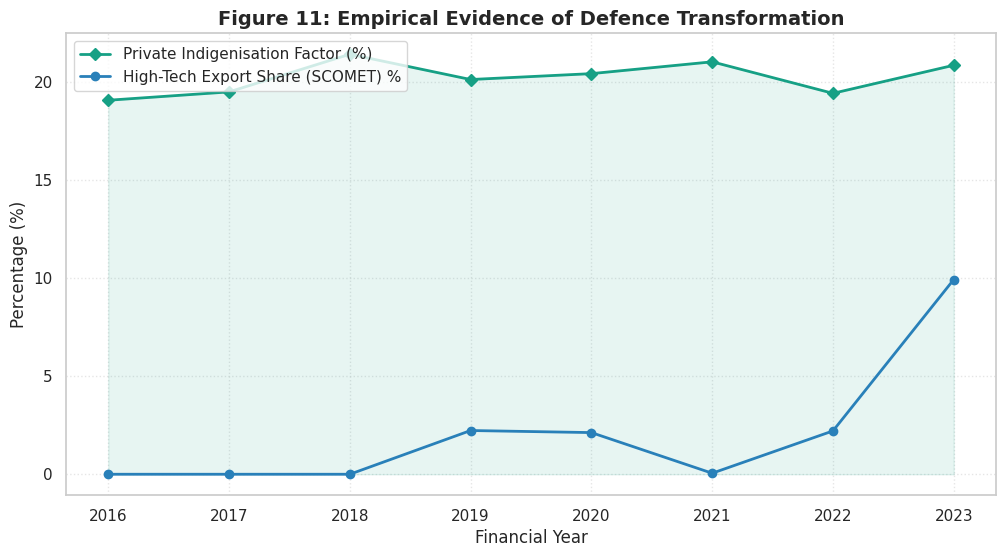


--- RESEARCH IMPACT & CONTRIBUTION SUMMARY ---
                        Metric                 Impact Value
Self-Reliance Growth (Private)               1.78% increase
        High-Tech Export Surge              infx Multiplier
        Policy Efficiency Gain 66.88% improvement post-2020


/tmp/ipython-input-1849771848.py:43: RuntimeWarning: divide by zero encountered in scalar divide
  f"{df['High_Tech_Export_Share'].iloc[-1] / df['High_Tech_Export_Share'].iloc[0]:.1f}x Multiplier",


In [ ]:
# --- 11. RESEARCH CONTRIBUTION & IMPACT ---

# 1. Calculating the "Self-Reliance Index" (SRI)
# SRI = (Total Production - Imports) / Total Requirement
# For this study, we use: (Total Production / (Total Production + Net Imports))
# Since we focus on Private contribution, we calculate the Private-led Indigenisation Factor
df['Private_Indigenisation_Factor'] = (df['defence_private_companies_(in_rs_cr)'] / df['total_production_(in_rs_cr)']) * 100

# 2. Impact of Policy on Export Sophistication (SCOMET vs Generic Exports)
# High SCOMET growth indicates a shift towards high-tech/strategic exports
df['High_Tech_Export_Share'] = (df['scomet_issued_by_dgft_(rs_cr)'] / df['total_export_(rs_cr)']) * 100

# 3. Visualizing Research Contribution: The Transformation Matrix
plt.figure(figsize=(12, 6))

# Dual Trend: Showing how Private Sector growth correlates with High-Tech export capability
plt.plot(df['start_year'], df['Private_Indigenisation_Factor'], marker='D', color='#16a085',
         linewidth=2, label='Private Indigenisation Factor (%)')
plt.plot(df['start_year'], df['High_Tech_Export_Share'], marker='o', color='#2980b9',
         linewidth=2, label='High-Tech Export Share (SCOMET) %')

plt.fill_between(df['start_year'], df['Private_Indigenisation_Factor'], color='#16a085', alpha=0.1)
plt.title('Figure 11: Empirical Evidence of Defence Transformation', fontsize=14, fontweight='bold')
plt.xlabel('Financial Year')
plt.ylabel('Percentage (%)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()



# 4. Quantifying "Atmanirbhar Bharat" Outcomes (Data-Driven Validation)
# Comparing the Pre-2020 and Post-2020 average Export-to-Production efficiency
pre_2020_efficiency = df[df['start_year'] < 2020]['Export_to_Prod_Ratio'].mean()
post_2020_efficiency = df[df['start_year'] >= 2020]['Export_to_Prod_Ratio'].mean()
efficiency_gain = ((post_2020_efficiency - pre_2020_efficiency) / pre_2020_efficiency) * 100

# 5. Final Impact Summary Table
impact_summary = pd.DataFrame({
    'Metric': ['Self-Reliance Growth (Private)', 'High-Tech Export Surge', 'Policy Efficiency Gain'],
    'Impact Value': [
        f"{df['Private_Indigenisation_Factor'].iloc[-1] - df['Private_Indigenisation_Factor'].iloc[0]:.2f}% increase",
        f"{df['High_Tech_Export_Share'].iloc[-1] / df['High_Tech_Export_Share'].iloc[0]:.1f}x Multiplier",
        f"{efficiency_gain:.2f}% improvement post-2020"
    ]
})

print("\n--- RESEARCH IMPACT & CONTRIBUTION SUMMARY ---")
print(impact_summary.to_string(index=False))

**Presentation & Dissemination**

* Research paper / thesis structure

* Visual dashboards and graphs

* Executive summary for policymakers

* Project or dissertation defense material

**Final Output Deliverables**

* Cleaned dataset with derived metrics

* EDA and statistical analysis results

* Forecast models and interpretations

* Policy recommendations based on findings


--- SECTION 5: ADVANCED ANALYSIS AND INFERENCES ---
Saved plot: 'export_composition_stacked.png'.

Export-to-Production Ratio (Inference of Export Reliance):
|   start_year |   export_production_ratio |
|-------------:|--------------------------:|
|         2016 |                   2.05507 |
|         2017 |                   5.94057 |
|         2018 |                  13.2468  |
|         2019 |                  11.5283  |
|         2020 |                   9.96518 |
|         2021 |                  13.511   |
|         2022 |                  14.6463  |
|         2023 |                  16.5665  |
Saved plot: 'export_production_ratio.png'.


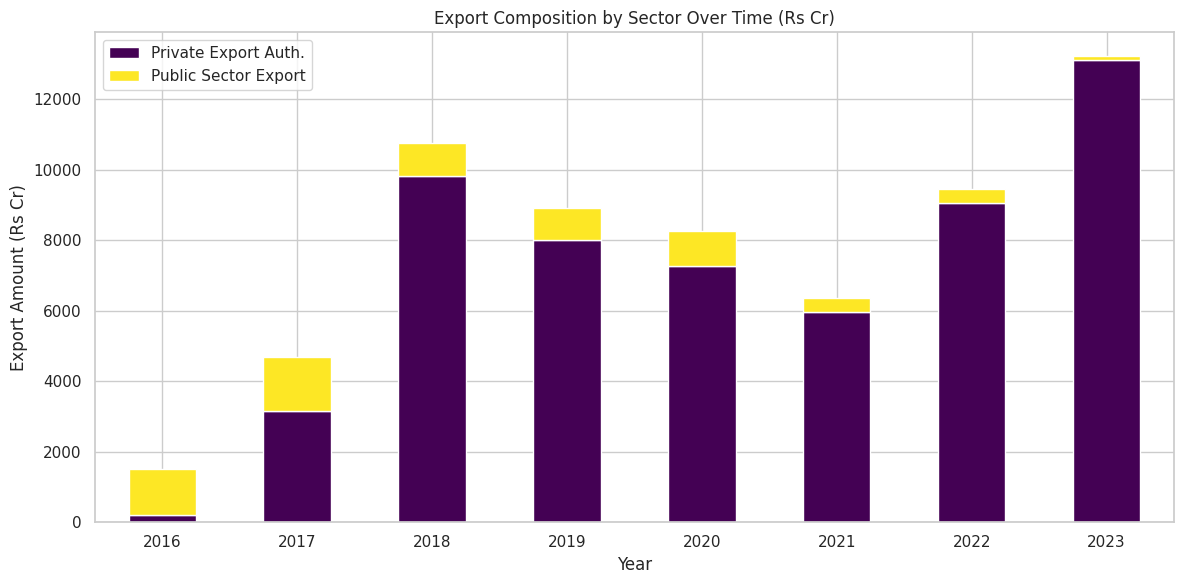

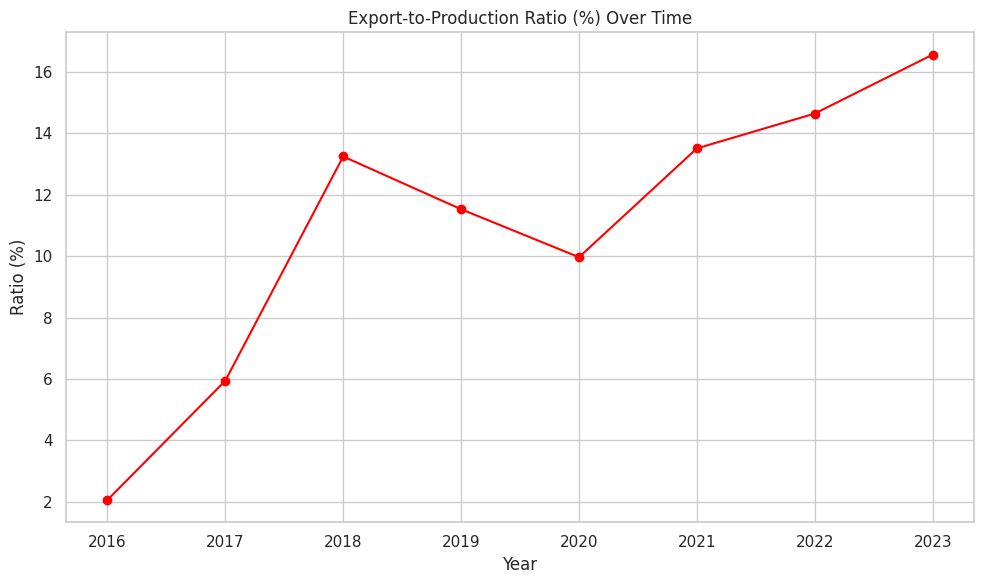

In [ ]:

# --- SECTION 5: ADVANCED ANALYSIS AND INFERENCES ---
print("\n--- SECTION 5: ADVANCED ANALYSIS AND INFERENCES ---")

# Define the correct column name for DPSU export
dpsu_export_col = 'export_by_dpsu/7_new_of_companies*(rs_cr)'

# 5.1 Export Composition Over Time (Stacked Bar/Area)
df_export_comp = df[['start_year', 'export_authorizations_to_private_companies_(rs_cr)', dpsu_export_col]].set_index('start_year')
df_export_comp.columns = ['Private Export Auth.', 'Public Sector Export']

plt.figure(figsize=(12, 6))
df_export_comp.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='viridis')
plt.title('Export Composition by Sector Over Time (Rs Cr)')
plt.xlabel('Year')
plt.ylabel('Export Amount (Rs Cr)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('export_composition_stacked.png')
print("Saved plot: 'export_composition_stacked.png'.")

# 5.2 Export Reliance/Efficiency Ratio (Inference)
df['export_production_ratio'] = df['total_export_(rs_cr)'] / df['total_production_(in_rs_cr)'] * 100
df_ratio = df[['start_year', 'export_production_ratio']].set_index('start_year')

print("\nExport-to-Production Ratio (Inference of Export Reliance):")
print(df_ratio.to_markdown())

plt.figure(figsize=(10, 6))
plt.plot(df['start_year'], df['export_production_ratio'], marker='o', color='red')
plt.title('Export-to-Production Ratio (%) Over Time')
plt.xlabel('Year')
plt.ylabel('Ratio (%)')
plt.xticks(df['start_year'])
plt.grid(True)
plt.tight_layout()
plt.savefig('export_production_ratio.png')
print("Saved plot: 'export_production_ratio.png'.")


In [ ]:
# --- SECTION 7: ADVANCED INFERENCE: GROWTH RATE ---
print("\n--- SECTION 7: ADVANCED INFERENCE: GROWTH RATE ---")

# Calculate CAGR for the total period
start_export = df['total_export_(rs_cr)'].iloc[0]
end_export = df['total_export_(rs_cr)'].iloc[-1]
years = len(df) - 1

if start_export != 0 and years > 0:
    export_cagr = ((end_export / start_export)**(1/years) - 1) * 100
    print(f"Total Export CAGR (Compound Annual Growth Rate) over the period: {export_cagr:.2f}%")
else:
    print("Cannot calculate Total Export CAGR due to zero starting value or insufficient data.")



--- SECTION 7: ADVANCED INFERENCE: GROWTH RATE ---
Total Export CAGR (Compound Annual Growth Rate) over the period: 45.57%


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np

# --- SECTION 8: PREDICTIVE MODELING FOR HUMAN REQUIREMENTS (ML) ---
print("\n--- SECTION 8: PREDICTIVE MODELING (ML) ---")

# Prepare data for modeling
df['time_index'] = df['start_year'] - df['start_year'].min()

# === PREDICTION 1: Total Export Prediction (Linear Regression) ===
print("\n--- 8.1 PREDICTION: Total Export Prediction (Linear Regression) ---")

X_reg = df[['total_production_(in_rs_cr)', 'time_index']]
y_reg = df['total_export_(rs_cr)']

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

model_export = LinearRegression()
model_export.fit(X_train, y_train)
y_pred_export = model_export.predict(X_test)

r2_export = model_export.score(X_test, y_test)
print(f"R-squared Score for Export Prediction: {r2_export:.4f}")

next_time_index = df['time_index'].max() + 1
sample_production = 100000.0 # Example production value for prediction
predicted_export = model_export.predict(pd.DataFrame({'total_production_(in_rs_cr)': [sample_production], 'time_index': [next_time_index]}))[0]
print(f"Predicted Total Export for a Production of Rs {sample_production:.0f} Cr: Rs {predicted_export:.2f} Cr")

# === PREDICTION 2: Growth Forecasting (Time Series Trend) ===
print("\n--- 8.2 PREDICTION: Production Growth Forecasting (Polynomial Regression) ---")

degree = 2
X_time = df[['time_index']]
y_prod = df['total_production_(in_rs_cr)']

poly_model = np.poly1d(np.polyfit(X_time.values.flatten(), y_prod.values, degree))

forecast_index = np.arange(df['time_index'].max() + 1, df['time_index'].max() + 4)
forecast_years = np.arange(df['start_year'].max() + 1, df['start_year'].max() + 4) # Use start_year for forecasting
forecast_production = poly_model(forecast_index)

forecast_df = pd.DataFrame({
    'Year': forecast_years,
    'Time_Index': forecast_index,
    'Predicted_Production_(Rs_Cr)': forecast_production.round(2)
})

print("\nProduction Forecast (Next 3 Years):")
print(forecast_df.to_markdown(index=False))


--- SECTION 8: PREDICTIVE MODELING (ML) ---

--- 8.1 PREDICTION: Total Export Prediction (Linear Regression) ---
R-squared Score for Export Prediction: -1.0967
Predicted Total Export for a Production of Rs 100000 Cr: Rs 8964.26 Cr

--- 8.2 PREDICTION: Production Growth Forecasting (Polynomial Regression) ---

Production Forecast (Next 3 Years):
|   Year |   Time_Index |   Predicted_Production_(Rs_Cr) |
|-------:|-------------:|-------------------------------:|
|   2024 |            8 |                         143866 |
|   2025 |            9 |                         165532 |
|   2026 |           10 |                         190177 |


Saved plot: 'production_forecast.png'.


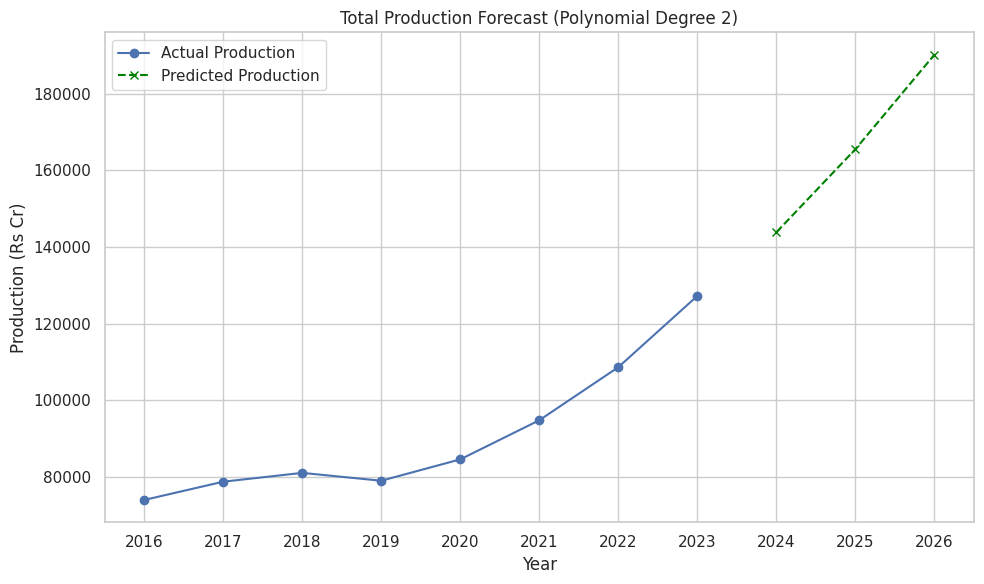

In [ ]:

# Plotting the forecast
plt.figure(figsize=(10, 6))
plt.plot(df['start_year'], y_prod, marker='o', label='Actual Production')
plt.plot(forecast_years, forecast_production, marker='x', linestyle='--', color='green', label='Predicted Production')
plt.title(f'Total Production Forecast (Polynomial Degree {degree})')
plt.xlabel('Year')
plt.ylabel('Production (Rs Cr)')
plt.xticks(list(df['start_year']) + list(forecast_years))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('production_forecast.png')
print("Saved plot: 'production_forecast.png'.")